<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Expansion_TIA_TAS_SBT_Full_Details.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- شروع اجرای نهایی با محاسبه SOF ---
--- Parameters: NUM_CELLS_X=4400, DT=6.7440e-13, PPC=100 ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 1/250 تمام شد. زمان سپری شده: 49.56 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 2/250 تمام شد. زمان سپری شده: 95.39 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 3/250 تمام شد. زمان سپری شده: 141.27 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 4/250 تمام شد. زمان سپری شده: 186.95 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 5/250 تمام شد. زمان سپری شده: 232.76 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 6/250 تمام شد. زمان سپری شده: 278.67 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 7/250 تمام شد. زمان سپری شده: 324.57 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 8/250 تمام شد. زمان سپری شده: 370.40 ثانیه ---
Initialized 242000 par

/tmp/ipython-input-1-2117214837.py:299: RuntimeWarning: Mean of empty slice
  averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)


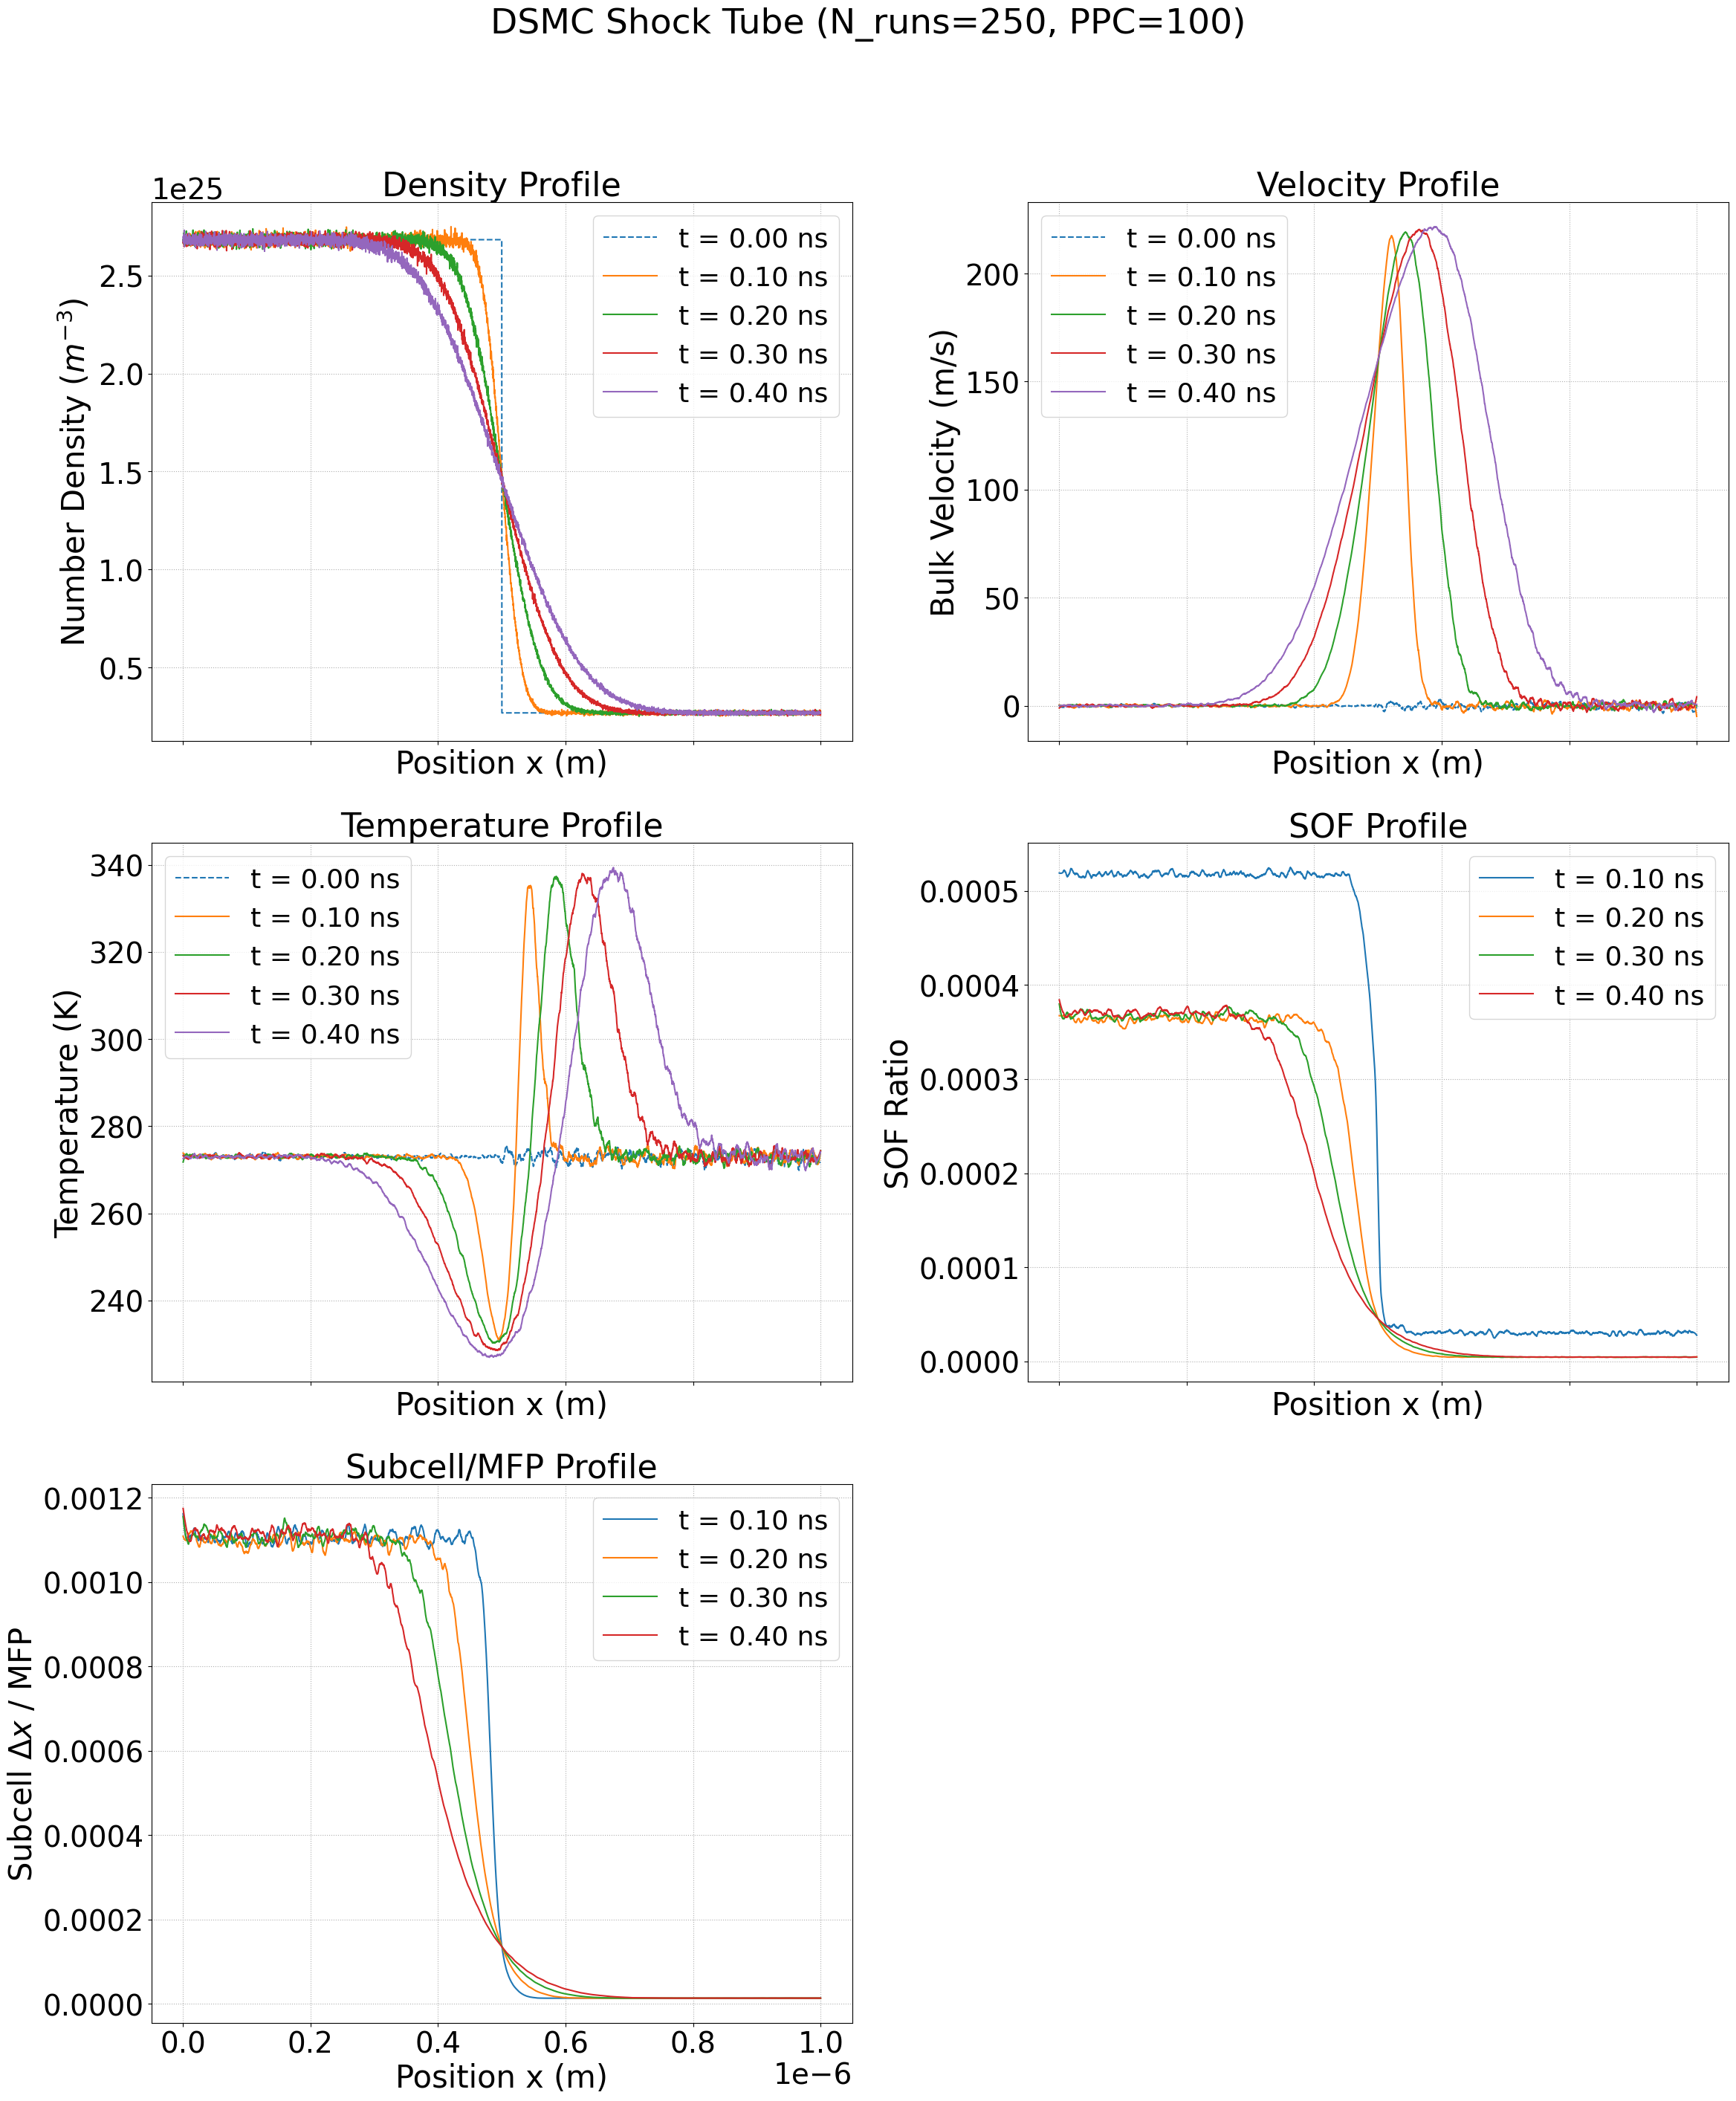

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.5 - Added Subcell/MFP Ratio Plot ---
# This version adds a 5th plot for the ratio of the subcell size to the
# local mean free path and arranges the plots in a 3x2 grid.

import numpy as np
import matplotlib.pyplot as plt
import numba
import time
from scipy.signal import savgol_filter
import pandas as pd

# ===================================================================
# 1. Simulation Core
# ===================================================================
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@numba.jit(nopython=True)
def perform_collisions_sbt_subcell(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, dist_sum_array, count_array, main_cell_idx):
    """
    Performs collisions using the SBT method with adaptive sub-cells.
    Also accumulates data for SOF parameter calculation.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                # --- SOF Calculation Data Accumulation ---
                # Calculate the separation distance between the colliding pair
                dist = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                dist_sum_array[main_cell_idx] += dist
                count_array[main_cell_idx] += 1
                # --- End SOF Data Accumulation ---

                # Standard collision mechanics
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS) # Ensure the final step is sampled

    results_history = {}
    cell_width = LX / NUM_CELLS_X

    # Sample initial state at t=0
    initial_props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)
    initial_props['sof'] = np.full(NUM_CELLS_X, np.nan) # SOF is not defined at t=0
    initial_props['subcell_mfp_ratio'] = np.full(NUM_CELLS_X, np.nan) # New parameter for t=0
    results_history[0.0] = initial_props

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    # --- Initialize accumulators for SOF calculation ---
    accumulated_dist_sum = np.zeros(NUM_CELLS_X, dtype=np.float64)
    accumulated_collision_count = np.zeros(NUM_CELLS_X, dtype=np.int64)

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)
            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts[:-1])))

            for i in range(NUM_CELLS_X):
                if cell_counts[i] > 1:
                    start = cell_start_indices[i]; end = start + cell_counts[i]
                    indices_in_cell_i = sorted_particle_indices[start:end]
                    cell_start_x = i * cell_width
                    perform_collisions_sbt_subcell(particles, indices_in_cell_i, cell_start_x, cell_width, subcell_config[i], CELL_VOLUME_CONCEPTUAL, DT, FNUM, accumulated_dist_sum, accumulated_collision_count, i)

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    # 1. Sample standard properties
                    props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

                    # 2. Calculate average collision distance from accumulated data
                    avg_dist = np.full(NUM_CELLS_X, np.nan, dtype=np.float64)
                    valid_counts = accumulated_collision_count > 0
                    avg_dist[valid_counts] = accumulated_dist_sum[valid_counts] / accumulated_collision_count[valid_counts]

                    # 3. Calculate Mean Free Path (MFP) for each cell
                    temp = props['temperature']
                    density = props['density'] # This is number density
                    mfp = np.full_like(temp, np.nan)
                    for cell_idx in range(NUM_CELLS_X):
                        if not np.isnan(temp[cell_idx]) and not np.isnan(density[cell_idx]) and temp[cell_idx] > 0 and density[cell_idx] > 0:
                            avg_vr = np.sqrt(16 * KB * temp[cell_idx] / (np.pi * MASS_AR))
                            avg_sigma = calculate_vhs_cross_section_numba(avg_vr)
                            mfp[cell_idx] = 1.0 / (density[cell_idx] * avg_sigma)

                    # 4. Calculate SOF parameter
                    with np.errstate(divide='ignore', invalid='ignore'):
                        sof = avg_dist / mfp
                    props['sof'] = sof

                    # 5. Calculate Subcell size to MFP ratio
                    subcell_size = cell_width / subcell_config # This is an array
                    with np.errstate(divide='ignore', invalid='ignore'):
                        subcell_mfp_ratio = subcell_size / mfp
                    props['subcell_mfp_ratio'] = subcell_mfp_ratio

                    # 6. Store results and reset accumulators
                    results_history[time_key] = props
                    accumulated_dist_sum.fill(0)
                    accumulated_collision_count.fill(0)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 100,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
    }
    NUM_ENSEMBLE_RUNS = 250

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        np.random.seed(int(time.time()) + i)
        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)
        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    data_keys_to_average = ['density', 'velocity', 'temperature', 'sof', 'subcell_mfp_ratio']

    for t in sample_times:
        for key in data_keys_to_average:
            all_data_for_t_and_key = [run[t][key] for run in all_results if t in run and key in run[t]]
            if all_data_for_t_and_key:
                averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # --- PLOTTING CHANGES START HERE ---

    plt.rcParams.update({
        'font.size': 28,
        'axes.labelsize': 30,
        'axes.titlesize': 32,
        'xtick.labelsize': 28,
        'ytick.labelsize': 28,
        'legend.fontsize': 26
    })

    # Create a 3x2 subplot layout to accommodate 5 plots
    fig, axes = plt.subplots(3, 2, figsize=(24, 30), sharex=True)
    axes_flat = axes.flatten()

    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=34)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes_flat[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes_flat[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes_flat[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes_flat[3], 'ylabel': 'SOF Ratio'},
        'Subcell/MFP': {'data_key': 'subcell_mfp_ratio', 'ax': axes_flat[4], 'ylabel': r'Subcell $\Delta x$ / MFP'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Apply smoothing to all noisy data types
                    if name in ['Velocity', 'Temperature', 'SOF', 'Subcell/MFP'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    # Hide the last unused subplot
    fig.delaxes(axes_flat[5])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_with_sof.eps", format='eps')
    plt.show()
    # --- PLOTTING CHANGES END HERE ---


In [ ]:
pip uninstall numba llvmlite -y

Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0


In [ ]:
pip install numba llvmlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 61.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 25.2.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cudf-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
distributed-ucxx-cu12 0.42.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cuml-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.


In [ ]:
pip uninstall numba llvmlite -y

Found existing installation: numba 0.61.2
Uninstalling numba-0.61.2:
  Successfully uninstalled numba-0.61.2
Found existing installation: llvmlite 0.44.0
Uninstalling llvmlite-0.44.0:
  Successfully uninstalled llvmlite-0.44.0


In [ ]:
pip install llvmlite==0.42.0
pip install numba==0.59.1

SyntaxError: invalid syntax (ipython-input-2-3666193935.py, line 1)

In [ ]:
import sys
import numpy
import llvmlite
import numba

print(f"Python version: {sys.version}")
print(f"Numpy version: {numpy.__version__}")
print(f"LLVMlite version: {llvmlite.__version__}")
print(f"Numba version: {numba.__version__}")

print("\n--- Checking Numba's GPU detection ---")
try:
    from numba import cuda
    if cuda.is_available():
        print("Numba found the following GPU(s):")
        print(cuda.gpus)
    else:
        print("Numba's CUDA driver is available, but no compatible GPU was found.")
except ImportError:
    print("Numba's CUDA driver is not available (this is normal for CPU-only execution).")
except Exception as e:
    print(f"An error occurred during Numba GPU check: {e}")



ModuleNotFoundError: No module named 'llvmlite'

In [ ]:
pip install llvmlite numba

  Using cached llvmlite-0.44.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
  Using cached numba-0.61.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.8 kB)
Using cached llvmlite-0.44.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (42.4 MB)
Using cached numba-0.61.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 25.2.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cudf-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
distributed-ucxx-cu12 0.42.0 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.
cuml-cu12 25.2.1 requires numba<0.61.0a0,>=0.59.1, but you have numba 0.61.2 which is incompatible.


Streaming output truncated to the last 5000 lines.
Initialized 24200 particles for Shock Tube problem.
--- اجرای 1/2500 تمام شد. زمان سپری شده: 13.02 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 2/2500 تمام شد. زمان سپری شده: 23.04 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 3/2500 تمام شد. زمان سپری شده: 33.00 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 4/2500 تمام شد. زمان سپری شده: 43.10 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 5/2500 تمام شد. زمان سپری شده: 53.18 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 6/2500 تمام شد. زمان سپری شده: 63.30 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 7/2500 تمام شد. زمان سپری شده: 73.31 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 8/2500 تمام شد. زمان سپری شده: 83.43 ثانیه ---
Initialized 24200 particles for Shock Tube problem.
--- اجرای 9/2500 تمام شد.

/tmp/ipython-input-1-2997460374.py:299: RuntimeWarning: Mean of empty slice
  averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)
/tmp/ipython-input-1-2997460374.py:299: RuntimeWarning: Mean of empty slice
  averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)


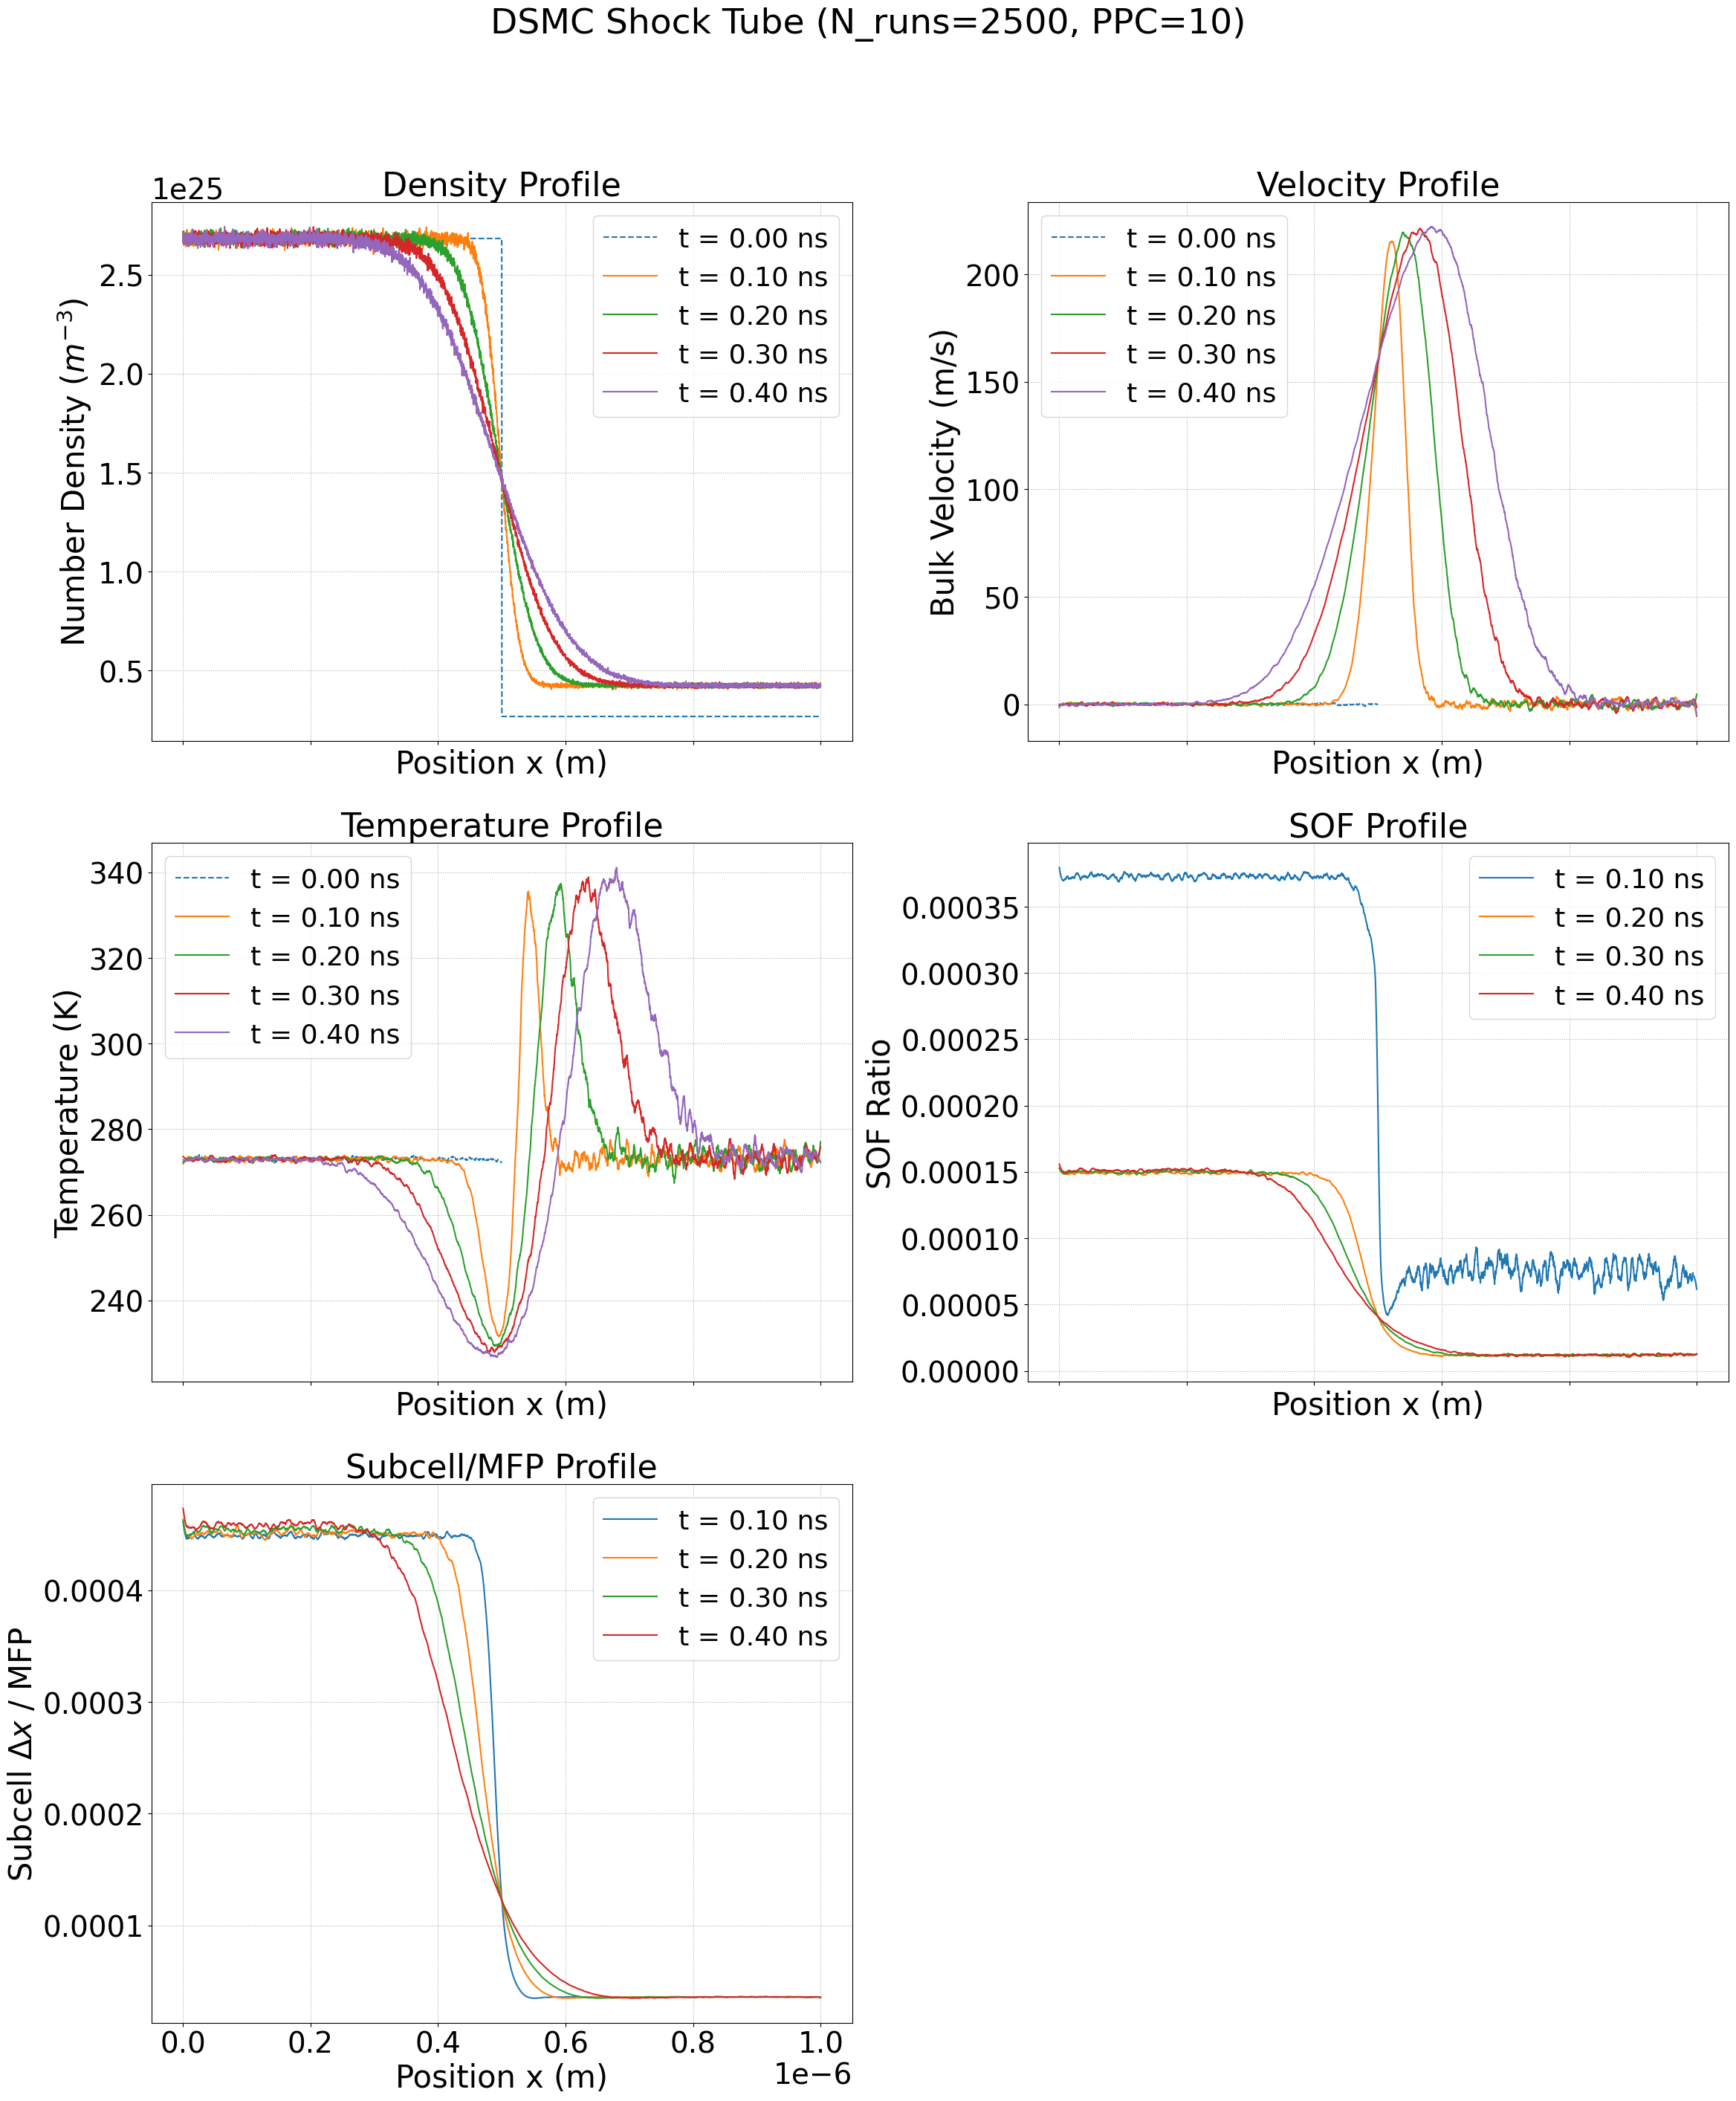

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.5 - Added Subcell/MFP Ratio Plot ---
# This version adds a 5th plot for the ratio of the subcell size to the
# local mean free path and arranges the plots in a 3x2 grid.

import numpy as np
import matplotlib.pyplot as plt
import numba
import time
from scipy.signal import savgol_filter
import pandas as pd

# ===================================================================
# 1. Simulation Core
# ===================================================================
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@numba.jit(nopython=True)
def perform_collisions_sbt_subcell(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, dist_sum_array, count_array, main_cell_idx):
    """
    Performs collisions using the SBT method with adaptive sub-cells.
    Also accumulates data for SOF parameter calculation.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                # --- SOF Calculation Data Accumulation ---
                # Calculate the separation distance between the colliding pair
                dist = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                dist_sum_array[main_cell_idx] += dist
                count_array[main_cell_idx] += 1
                # --- End SOF Data Accumulation ---

                # Standard collision mechanics
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS) # Ensure the final step is sampled

    results_history = {}
    cell_width = LX / NUM_CELLS_X

    # Sample initial state at t=0
    initial_props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)
    initial_props['sof'] = np.full(NUM_CELLS_X, np.nan) # SOF is not defined at t=0
    initial_props['subcell_mfp_ratio'] = np.full(NUM_CELLS_X, np.nan) # New parameter for t=0
    results_history[0.0] = initial_props

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    # --- Initialize accumulators for SOF calculation ---
    accumulated_dist_sum = np.zeros(NUM_CELLS_X, dtype=np.float64)
    accumulated_collision_count = np.zeros(NUM_CELLS_X, dtype=np.int64)

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)
            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts[:-1])))

            for i in range(NUM_CELLS_X):
                if cell_counts[i] > 1:
                    start = cell_start_indices[i]; end = start + cell_counts[i]
                    indices_in_cell_i = sorted_particle_indices[start:end]
                    cell_start_x = i * cell_width
                    perform_collisions_sbt_subcell(particles, indices_in_cell_i, cell_start_x, cell_width, subcell_config[i], CELL_VOLUME_CONCEPTUAL, DT, FNUM, accumulated_dist_sum, accumulated_collision_count, i)

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    # 1. Sample standard properties
                    props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

                    # 2. Calculate average collision distance from accumulated data
                    avg_dist = np.full(NUM_CELLS_X, np.nan, dtype=np.float64)
                    valid_counts = accumulated_collision_count > 0
                    avg_dist[valid_counts] = accumulated_dist_sum[valid_counts] / accumulated_collision_count[valid_counts]

                    # 3. Calculate Mean Free Path (MFP) for each cell
                    temp = props['temperature']
                    density = props['density'] # This is number density
                    mfp = np.full_like(temp, np.nan)
                    for cell_idx in range(NUM_CELLS_X):
                        if not np.isnan(temp[cell_idx]) and not np.isnan(density[cell_idx]) and temp[cell_idx] > 0 and density[cell_idx] > 0:
                            avg_vr = np.sqrt(16 * KB * temp[cell_idx] / (np.pi * MASS_AR))
                            avg_sigma = calculate_vhs_cross_section_numba(avg_vr)
                            mfp[cell_idx] = 1.0 / (density[cell_idx] * avg_sigma)

                    # 4. Calculate SOF parameter
                    with np.errstate(divide='ignore', invalid='ignore'):
                        sof = avg_dist / mfp
                    props['sof'] = sof

                    # 5. Calculate Subcell size to MFP ratio
                    subcell_size = cell_width / subcell_config # This is an array
                    with np.errstate(divide='ignore', invalid='ignore'):
                        subcell_mfp_ratio = subcell_size / mfp
                    props['subcell_mfp_ratio'] = subcell_mfp_ratio

                    # 6. Store results and reset accumulators
                    results_history[time_key] = props
                    accumulated_dist_sum.fill(0)
                    accumulated_collision_count.fill(0)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
    if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 4400,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 10,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
    }
    NUM_ENSEMBLE_RUNS = 2500

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        np.random.seed(int(time.time()) + i)
        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)
        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    data_keys_to_average = ['density', 'velocity', 'temperature', 'sof', 'subcell_mfp_ratio']

    for t in sample_times:
        for key in data_keys_to_average:
            all_data_for_t_and_key = [run[t][key] for run in all_results if t in run and key in run[t]]
            if all_data_for_t_and_key:
                averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # --- PLOTTING CHANGES START HERE ---

    plt.rcParams.update({
        'font.size': 28,
        'axes.labelsize': 30,
        'axes.titlesize': 32,
        'xtick.labelsize': 28,
        'ytick.labelsize': 28,
        'legend.fontsize': 26
    })

    # Create a 3x2 subplot layout to accommodate 5 plots
    fig, axes = plt.subplots(3, 2, figsize=(24, 30), sharex=True)
    axes_flat = axes.flatten()

    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=34)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes_flat[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes_flat[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes_flat[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes_flat[3], 'ylabel': 'SOF Ratio'},
        'Subcell/MFP': {'data_key': 'subcell_mfp_ratio', 'ax': axes_flat[4], 'ylabel': r'Subcell $\Delta x$ / MFP'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Apply smoothing to all noisy data types
                    if name in ['Velocity', 'Temperature', 'SOF', 'Subcell/MFP'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    # Hide the last unused subplot
    fig.delaxes(axes_flat[5])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_with_sof.eps", format='eps')
    plt.show()
    # --- PLOTTING CHANGES END HERE ---


--- شروع اجرای نهایی با محاسبه SOF ---
--- Parameters: NUM_CELLS_X=44000, DT=6.7440e-13, PPC=10 ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 1/5 تمام شد. زمان سپری شده: 111.06 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 2/5 تمام شد. زمان سپری شده: 221.04 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 3/5 تمام شد. زمان سپری شده: 330.14 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 4/5 تمام شد. زمان سپری شده: 439.31 ثانیه ---
Initialized 242000 particles for Shock Tube problem.
--- اجرای 5/5 تمام شد. زمان سپری شده: 548.23 ثانیه ---


/tmp/ipython-input-4-1250250859.py:299: RuntimeWarning: Mean of empty slice
  averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)


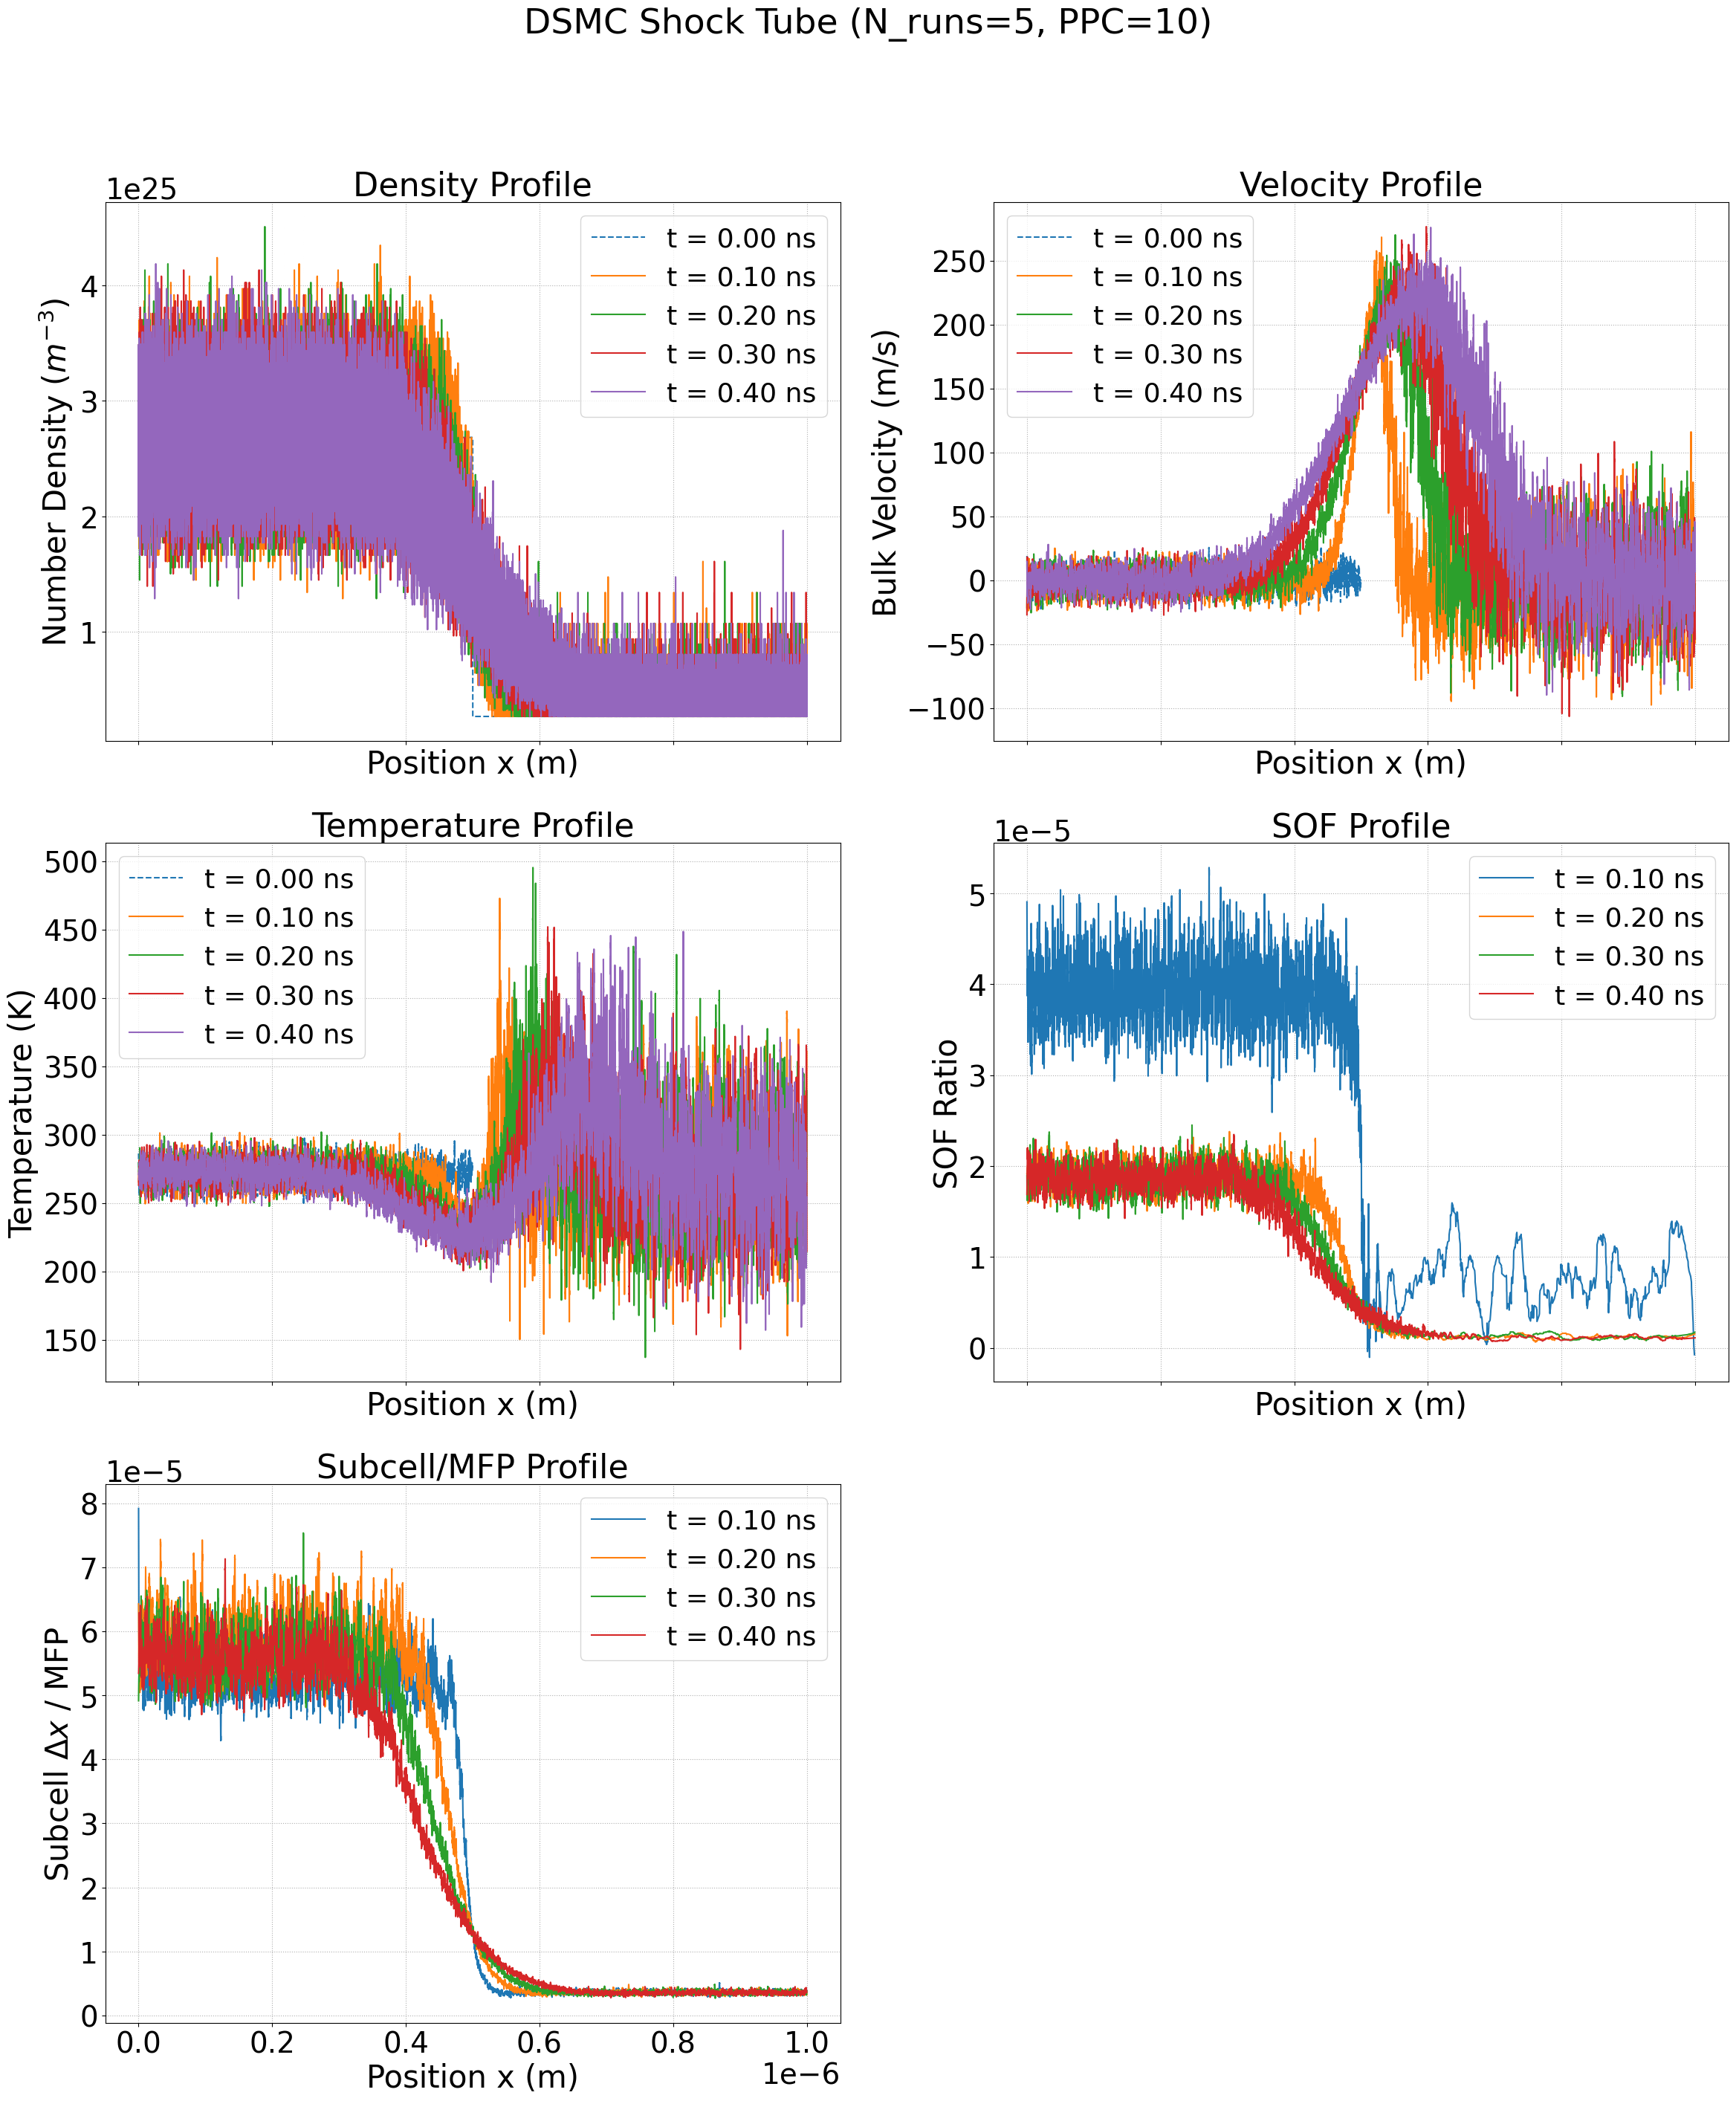

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC CODE - V27.5 - Added Subcell/MFP Ratio Plot ---
# This version adds a 5th plot for the ratio of the subcell size to the
# local mean free path and arranges the plots in a 3x2 grid.

import numpy as np
import matplotlib.pyplot as plt
import numba
import time
from scipy.signal import savgol_filter
import pandas as pd

# ===================================================================
# 1. Simulation Core
# ===================================================================
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23

@numba.jit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    d_ref = 4.17e-10
    t_ref = 273.0
    omega_vhs = 0.81
    if vr_mag < 1e-9: return 1e-30
    exponent = omega_vhs - 0.5
    c_ref_sq = 2 * KB * t_ref / MASS_AR
    gamma_val = 1.04533
    d_sq = (d_ref**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

@numba.jit(nopython=True)
def perform_collisions_sbt_subcell(particles, indices_in_cell, cell_start_x, cell_width, num_sub_cells, cell_vol, dt, fnum, dist_sum_array, count_array, main_cell_idx):
    """
    Performs collisions using the SBT method with adaptive sub-cells.
    Also accumulates data for SOF parameter calculation.
    """
    num_particles_in_main_cell = len(indices_in_cell)
    if num_particles_in_main_cell < 2: return

    num_sub_cells = max(1, num_sub_cells)
    sub_cell_width = cell_width / num_sub_cells

    sub_cell_groups = [[np.int64(x) for x in range(0)] for _ in range(num_sub_cells)]

    for p_idx in indices_in_cell:
        relative_pos = particles[p_idx, 0] - cell_start_x
        sub_cell_idx = int(relative_pos / sub_cell_width)
        if 0 <= sub_cell_idx < num_sub_cells:
            sub_cell_groups[sub_cell_idx].append(p_idx)

    sub_cell_vol = cell_vol / num_sub_cells
    if sub_cell_vol < 1e-30: return

    for sc_idx in range(num_sub_cells):
        indices_in_sub_cell = sub_cell_groups[sc_idx]
        num_particles_in_sub_cell = len(indices_in_sub_cell)
        if num_particles_in_sub_cell < 2: continue

        for i in range(num_particles_in_sub_cell - 1):
            p1_idx = indices_in_sub_cell[i]
            remaining_particles_count = num_particles_in_sub_cell - (i + 1)
            j_offset = np.random.randint(0, remaining_particles_count)
            j = i + 1 + j_offset
            p2_idx = indices_in_sub_cell[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            weighting_factor = float(remaining_particles_count)
            collision_prob = (weighting_factor * fnum * dt * sigma_t * vr_mag) / sub_cell_vol

            if np.random.rand() < collision_prob:
                # --- SOF Calculation Data Accumulation ---
                # Calculate the separation distance between the colliding pair
                dist = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                dist_sum_array[main_cell_idx] += dist
                count_array[main_cell_idx] += 1
                # --- End SOF Data Accumulation ---

                # Standard collision mechanics
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * np.random.rand() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * np.random.rand()
                vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

def run_dsmc_simulation(sim_params):
    """Main DSMC simulation loop."""
    LX = sim_params['LX']; RHO_INIT = sim_params['RHO_INIT']; T_INIT = sim_params['T_INIT']
    NUM_CELLS_X = sim_params['NUM_CELLS_X']; PARTICLES_PER_CELL_INIT = sim_params['PARTICLES_PER_CELL_INIT']
    TOTAL_TIME = sim_params['TOTAL_TIME']; DT = sim_params['DT']
    MIN_PARTICLES_FOR_STATS = 2
    MAX_SUB_CELLS = sim_params['MAX_SUB_CELLS']
    ADAPTATION_INTERVAL = sim_params['ADAPTATION_INTERVAL']

    particles = initialize_shock_tube(sim_params)

    N_DENSITY_REAL = RHO_INIT / MASS_AR
    CELL_VOLUME_CONCEPTUAL = (LX / NUM_CELLS_X) * ((LX/10) * (LX/10))
    FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
    NUM_STEPS = int(TOTAL_TIME / DT)

    sample_points_in_time = np.linspace(0, TOTAL_TIME, 5)
    sample_steps = {int(round(t / DT)) for t in sample_points_in_time}
    sample_steps.add(NUM_STEPS) # Ensure the final step is sampled

    results_history = {}
    cell_width = LX / NUM_CELLS_X

    # Sample initial state at t=0
    initial_props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)
    initial_props['sof'] = np.full(NUM_CELLS_X, np.nan) # SOF is not defined at t=0
    initial_props['subcell_mfp_ratio'] = np.full(NUM_CELLS_X, np.nan) # New parameter for t=0
    results_history[0.0] = initial_props

    subcell_config = np.ones(NUM_CELLS_X, dtype=np.int32)

    # --- Initialize accumulators for SOF calculation ---
    accumulated_dist_sum = np.zeros(NUM_CELLS_X, dtype=np.float64)
    accumulated_collision_count = np.zeros(NUM_CELLS_X, dtype=np.int64)

    current_step = 0
    while current_step < NUM_STEPS:
        sum_cell_counts = np.zeros(NUM_CELLS_X, dtype=np.int64)
        steps_in_block = min(ADAPTATION_INTERVAL, NUM_STEPS - current_step)

        for _ in range(steps_in_block):
            current_step += 1
            if current_step > NUM_STEPS: break

            particles[:, 0] += particles[:, 1] * DT
            hit_left = particles[:, 0] < 0; particles[hit_left, 1] *= -1; particles[hit_left, 0] *= -1
            hit_right = particles[:, 0] > LX; particles[hit_right, 1] *= -1; particles[hit_right, 0] = 2 * LX - particles[hit_right, 0]

            cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
            cell_indices = np.clip(cell_indices, 0, NUM_CELLS_X - 1)
            sorted_particle_indices = np.argsort(cell_indices)
            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)

            sum_cell_counts += cell_counts
            cell_start_indices = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(cell_counts[:-1])))

            for i in range(NUM_CELLS_X):
                if cell_counts[i] > 1:
                    start = cell_start_indices[i]; end = start + cell_counts[i]
                    indices_in_cell_i = sorted_particle_indices[start:end]
                    cell_start_x = i * cell_width
                    perform_collisions_sbt_subcell(particles, indices_in_cell_i, cell_start_x, cell_width, subcell_config[i], CELL_VOLUME_CONCEPTUAL, DT, FNUM, accumulated_dist_sum, accumulated_collision_count, i)

            if current_step in sample_steps:
                time_key = current_step * DT
                if abs(time_key) > 1e-15:
                    # 1. Sample standard properties
                    props = sample_properties(particles, NUM_CELLS_X, cell_width, FNUM, CELL_VOLUME_CONCEPTUAL, MIN_PARTICLES_FOR_STATS)

                    # 2. Calculate average collision distance from accumulated data
                    avg_dist = np.full(NUM_CELLS_X, np.nan, dtype=np.float64)
                    valid_counts = accumulated_collision_count > 0
                    avg_dist[valid_counts] = accumulated_dist_sum[valid_counts] / accumulated_collision_count[valid_counts]

                    # 3. Calculate Mean Free Path (MFP) for each cell
                    temp = props['temperature']
                    density = props['density'] # This is number density
                    mfp = np.full_like(temp, np.nan)
                    for cell_idx in range(NUM_CELLS_X):
                        if not np.isnan(temp[cell_idx]) and not np.isnan(density[cell_idx]) and temp[cell_idx] > 0 and density[cell_idx] > 0:
                            avg_vr = np.sqrt(16 * KB * temp[cell_idx] / (np.pi * MASS_AR))
                            avg_sigma = calculate_vhs_cross_section_numba(avg_vr)
                            mfp[cell_idx] = 1.0 / (density[cell_idx] * avg_sigma)

                    # 4. Calculate SOF parameter
                    with np.errstate(divide='ignore', invalid='ignore'):
                        sof = avg_dist / mfp
                    props['sof'] = sof

                    # 5. Calculate Subcell size to MFP ratio
                    subcell_size = cell_width / subcell_config # This is an array
                    with np.errstate(divide='ignore', invalid='ignore'):
                        subcell_mfp_ratio = subcell_size / mfp
                    props['subcell_mfp_ratio'] = subcell_mfp_ratio

                    # 6. Store results and reset accumulators
                    results_history[time_key] = props
                    accumulated_dist_sum.fill(0)
                    accumulated_collision_count.fill(0)

        avg_cell_counts = sum_cell_counts / steps_in_block
        max_avg_count = np.max(avg_cell_counts)
        if max_avg_count > 1e-9:
            normalized_density = avg_cell_counts / max_avg_count
            adaptive_rule = 1.0 - normalized_density
            subcell_config = np.clip(1 + ((MAX_SUB_CELLS - 1) * adaptive_rule).astype(np.int32), 1, MAX_SUB_CELLS)

    return results_history

def initialize_shock_tube(params):
    """Initializes particle positions and velocities."""
    num_cells = params['NUM_CELLS_X']; lx = params['LX']
    ppc_left = params['PARTICLES_PER_CELL_INIT']; t_left = params['T_INIT']
    rho_ratio = params['RHO_RATIO']
    ppc_right = int(ppc_left / rho_ratio)
   # if ppc_right < 1: ppc_right = 1

    num_cells_left = num_cells // 2
    num_cells_right = num_cells - num_cells_left
    total_particles = (ppc_left * num_cells_left) + (ppc_right * num_cells_right)
    particles = np.zeros((total_particles, 4))

    cell_width = lx / num_cells
    v_thermal_std = np.sqrt(KB * t_left / MASS_AR)

    current_pos = 0
    for i in range(num_cells_left):
        start_idx = current_pos; end_idx = start_idx + ppc_left
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_left) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_left, 3))
        current_pos = end_idx
    for i in range(num_cells_left, num_cells):
        start_idx = current_pos; end_idx = start_idx + ppc_right
        particles[start_idx:end_idx, 0] = i * cell_width + np.random.rand(ppc_right) * cell_width
        particles[start_idx:end_idx, 1:4] = np.random.normal(0, v_thermal_std, (ppc_right, 3))
        current_pos = end_idx

    print(f"Initialized {total_particles} particles for Shock Tube problem.")
    return particles

def sample_properties(particles_state, num_cells, cell_width, fnum, cell_vol, min_parts):
    """Samples macroscopic properties from particle data."""
    density_profile = np.full(num_cells, np.nan)
    velocity_profile = np.full(num_cells, np.nan)
    temp_profile = np.full(num_cells, np.nan)

    cell_indices = (particles_state[:, 0] / cell_width).astype(np.int64)
    cell_indices = np.clip(cell_indices, 0, num_cells - 1)

    sorted_indices = np.argsort(cell_indices)
    counts = np.bincount(cell_indices, minlength=num_cells)
    starts = np.concatenate((np.array([0], dtype=np.int64), np.cumsum(counts[:-1])))

    for i in range(num_cells):
        num_in_cell = counts[i]
        if num_in_cell > 0:
            density_profile[i] = num_in_cell * fnum / cell_vol
        if num_in_cell >= min_parts:
            indices_in_cell_i = sorted_indices[starts[i]:starts[i]+num_in_cell]
            cell_velocities = particles_state[indices_in_cell_i, 1:4]
            mean_vel_cell = np.mean(cell_velocities, axis=0)
            velocity_profile[i] = mean_vel_cell[0]

            thermal_vel_sq = np.sum((cell_velocities - mean_vel_cell)**2)
            if num_in_cell > 1:
                temp_profile[i] = (MASS_AR * thermal_vel_sq) / (3 * KB * (num_in_cell - 1))
            else:
                temp_profile[i] = 0.0

    return {'density': density_profile, 'velocity': velocity_profile, 'temperature': temp_profile}

# ===================================================================
# 2. Main Execution Block
# ===================================================================
if __name__ == "__main__":
    SIMULATION_PARAMS = {
        'LX': 1.0e-6, 'RHO_INIT': 1.78, 'T_INIT': 273.0,
        'NUM_CELLS_X': 44000,
        'DT': 6.744e-13,
        'PARTICLES_PER_CELL_INIT': 1,
        'TOTAL_TIME': 0.4e-9,
        'RHO_RATIO': 10.0,
        'MAX_SUB_CELLS': 20,
        'ADAPTATION_INTERVAL': 50,
    }
    NUM_ENSEMBLE_RUNS = 5

    print(f"--- شروع اجرای نهایی با محاسبه SOF ---")
    print(f"--- Parameters: NUM_CELLS_X={SIMULATION_PARAMS['NUM_CELLS_X']}, DT={SIMULATION_PARAMS['DT']:.4e}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']} ---")

    all_results = []
    start_time_total = time.time()
    for i in range(NUM_ENSEMBLE_RUNS):
        np.random.seed(int(time.time()) + i)
        single_run_history = run_dsmc_simulation(SIMULATION_PARAMS)
        all_results.append(single_run_history)
        print(f"--- اجرای {i+1}/{NUM_ENSEMBLE_RUNS} تمام شد. زمان سپری شده: {time.time() - start_time_total:.2f} ثانیه ---")

    sample_times = sorted(all_results[0].keys())
    averaged_results = {t: {} for t in sample_times}

    data_keys_to_average = ['density', 'velocity', 'temperature', 'sof', 'subcell_mfp_ratio']

    for t in sample_times:
        for key in data_keys_to_average:
            all_data_for_t_and_key = [run[t][key] for run in all_results if t in run and key in run[t]]
            if all_data_for_t_and_key:
                averaged_results[t][key] = np.nanmean(np.array(all_data_for_t_and_key), axis=0)

    cell_width = SIMULATION_PARAMS['LX'] / SIMULATION_PARAMS['NUM_CELLS_X']
    cell_centers = (np.arange(SIMULATION_PARAMS['NUM_CELLS_X']) + 0.5) * cell_width

    # --- PLOTTING CHANGES START HERE ---

    plt.rcParams.update({
        'font.size': 28,
        'axes.labelsize': 30,
        'axes.titlesize': 32,
        'xtick.labelsize': 28,
        'ytick.labelsize': 28,
        'legend.fontsize': 26
    })

    # Create a 3x2 subplot layout to accommodate 5 plots
    fig, axes = plt.subplots(3, 2, figsize=(24, 30), sharex=True)
    axes_flat = axes.flatten()

    fig.suptitle(f"DSMC Shock Tube (N_runs={NUM_ENSEMBLE_RUNS}, PPC={SIMULATION_PARAMS['PARTICLES_PER_CELL_INIT']})", fontsize=34)

    plot_info = {
        'Density': {'data_key': 'density', 'ax': axes_flat[0], 'ylabel': 'Number Density ($m^{-3}$)'},
        'Velocity': {'data_key': 'velocity', 'ax': axes_flat[1], 'ylabel': 'Bulk Velocity (m/s)'},
        'Temperature': {'data_key': 'temperature', 'ax': axes_flat[2], 'ylabel': 'Temperature (K)'},
        'SOF': {'data_key': 'sof', 'ax': axes_flat[3], 'ylabel': 'SOF Ratio'},
        'Subcell/MFP': {'data_key': 'subcell_mfp_ratio', 'ax': axes_flat[4], 'ylabel': r'Subcell $\Delta x$ / MFP'}
    }

    for name, p_info in plot_info.items():
        ax = p_info['ax']
        for t in sample_times:
            if t in averaged_results and p_info['data_key'] in averaged_results[t]:
                s_data = pd.Series(averaged_results[t][p_info['data_key']])
                valid_indices = ~s_data.isna()
                label_text = f't = {t*1e9:.2f} ns'
                line_style = '--' if abs(t) < 1e-12 else '-'

                if np.sum(valid_indices) > 0:
                    # Apply smoothing to all noisy data types
                    if name in ['Velocity', 'Temperature', 'SOF', 'Subcell/MFP'] and np.sum(valid_indices) > 51:
                        smoothed_data = savgol_filter(s_data[valid_indices], window_length=51, polyorder=2)
                        ax.plot(cell_centers[valid_indices], smoothed_data, linestyle=line_style, label=label_text)
                    else:
                        ax.plot(cell_centers[valid_indices], s_data[valid_indices], linestyle=line_style, label=label_text)

        ax.set_xlabel('Position x (m)')
        ax.set_ylabel(p_info['ylabel'])
        ax.set_title(f"{name} Profile")
        ax.grid(True, linestyle=':')
        ax.legend()

    # Hide the last unused subplot
    fig.delaxes(axes_flat[5])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("dsmc_final_results_with_sof.eps", format='eps')
    plt.show()
    # --- PLOTTING CHANGES END HERE ---
